## Uppgift 13

--- Personalöversikt ---
left
0    0.761917
1    0.238083
Name: proportion, dtype: float64


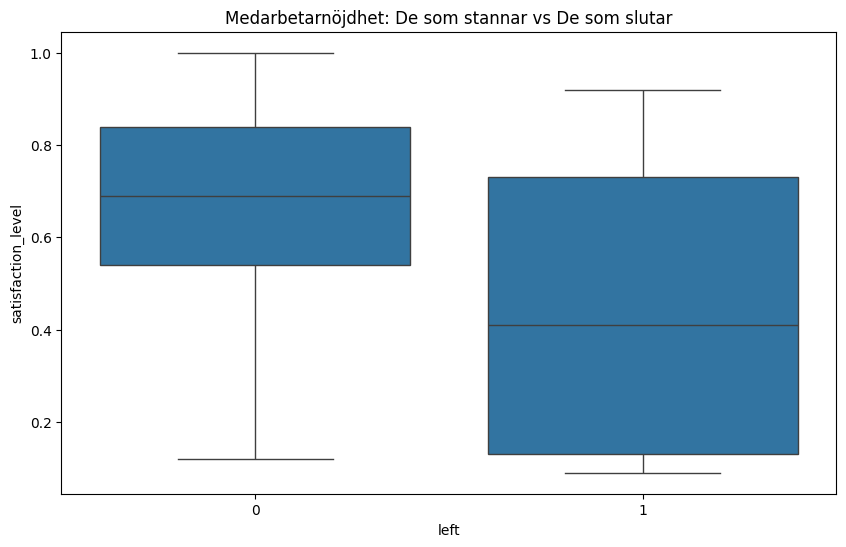

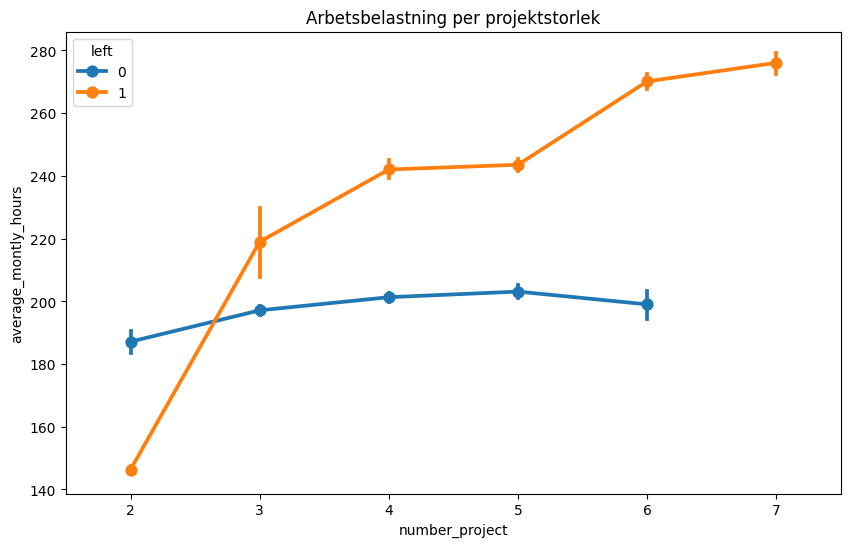

In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ladda data
df = pd.read_excel('hr_employee_data.xlsx')

# Övergripande statistik för ledningen
print("--- Personalöversikt ---")
print(df['left'].value_counts(normalize=True)) # Visar % som slutat

# Visualisering: Nöjdhet vs Personalomsättning
plt.figure(figsize=(10,6))
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title('Medarbetarnöjdhet: De som stannar vs De som slutar')
plt.show()

# Visualisering: Arbetstid vs Antal projekt
plt.figure(figsize=(10,6))
sns.pointplot(x='number_project', y='average_montly_hours', hue='left', data=df)
plt.title('Arbetsbelastning per projektstorlek')
plt.show()


## Uppgift 14

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
print(data.DESCR)
# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.info())
print(y.info())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initiera modellen
model = LinearRegression()

# 2. Träna modellen med träningsdatan
model.fit(X_train, y_train)

# 3. Gör förutsägelser på testdatan
y_pred = model.predict(X_test)

# 4. Utvärdera modellen
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Modellens RMSE (felmarginal): {rmse:.2f}")
print(f"R2-score (förklaringsgrad): {r2:.2f}")

Modellens RMSE (felmarginal): 53.85
R2-score (förklaringsgrad): 0.45


## Uppgift 15

In [4]:
#A)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("car_price_dataset.csv", sep=";")
df.head()


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [5]:
# Gör om textkategorier till siffror
df_prepared = pd.get_dummies(df, drop_first=True)

# Definiera X (allt utom priset) och y (priset vi vill gissa)
X = df_prepared.drop('Price', axis=1)
y = df_prepared['Price']

# Dela upp i träning test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data förberedd! Träningssetet har", X_train.shape[0], "rader.")

Data förberedd! Träningssetet har 8000 rader.


In [6]:
# Skapa och träna modellen
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Genomsnittligt fel (MAE): {mae:.0f} kr")
print(f"Modellens förklaringsgrad (R2): {r2:.2f}")

Genomsnittligt fel (MAE): 439 kr
Modellens förklaringsgrad (R2): 0.97


In [7]:
# B)
import pickle

# Spara modellen till en fil
with open('car_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Spara kolumnnamnen 
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

C Står i text dokumentet